In [1]:
#directorio raiz donde esta el framework
%cd D:\tesis\scrpt pyton\interfaz_correccion\interfaz_correccion\efficient-kan\src\efficient_kan

D:\tesis\scrpt pyton\interfaz_correccion\interfaz_correccion\efficient-kan\src\efficient_kan


C:\Users\ferro\AppData\Roaming\Python\Python312\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import pandas as pd
import numpy as np
import os
import joblib
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, auc, ConfusionMatrixDisplay
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import OneCycleLR
from entmax import sparsemax, entmax15
from lion_pytorch import Lion
from kan import KANLinear, KAN
import shap
import lime
import lime.lime_tabular
# Configuración para usar la GPU si está disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from sklearn.preprocessing import LabelEncoder

In [3]:
# Establecer semillas para reproducibilidad
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [4]:
# Cargar el dataset desde un archivo Excel
daf = pd.read_excel('D:\\tesis\\Modelo_extraccion_no\\dataset_extraccion_up_low_bimax.xlsx')
daf.columns

Index(['Paciente', 'Edad', 'Genero', 'Etnia', 'Apiñamiento sup',
       'Apiñamiento inf', 'Overbite', 'Overjet', 'SNA', 'SNB', 'ANB',
       'A-Macna', 'Pg-Macna', 'IMPA', 'SN-MP', 'SN-GoGn', 'Fh-Npog',
       'Ngo-GoMe', 'NS-SGn', 'U1-Sn', 'U1-PP', 'U1-NA(mm)', 'U1-Na(°)',
       'L1-NB(mm)', 'L1-NB(°)', 'U1-L1', 'L1-Apog', 'U1-Apog', 'Sts-Sti',
       'UL-E-Line', 'LL-E-Line', 'UlSn-SnPmn', 'LLB'-B'Pog'',
       'discrepancia total inferior', 'discrepancia total superior',
       'Clasificación  esqueletica', 'Relación molar', 'Relación premolar',
       'Relacion canina', 'Clase real', 'Extraccion / no extraccion inf',
       'Extraccion / no extraccion sup', 'Extraccion tejidos blandos',
       'Extraccion / no extraccion', 'Tipo de extraccióin global'],
      dtype='object')

In [5]:
daf.drop(columns=["Extraccion / no extraccion inf","Extraccion / no extraccion sup", "Extraccion / no extraccion","Paciente","Extraccion tejidos blandos",'discrepancia total inferior', 'discrepancia total superior',"Clase real"],inplace=True)
daf

,Edad,Genero,Etnia,Apiñamiento sup,Apiñamiento inf,Overbite,Overjet,SNA,SNB,ANB,...,Sts-Sti,UL-E-Line,LL-E-Line,UlSn-SnPmn,LLB'-B'Pog',Clasificación esqueletica,Relación molar,Relación premolar,Relacion canina,Tipo de extraccióin global
0,39,F,afrocolombiana,-4.00,-16.0,5.945810,2.202145,84.573158,82.968865,-1.604293,...,0.220212,-4.876738,0.516159,88.976967,153.536996,Clase 3,clase 1,clase 1,clase 2,Extracción bima
1,29,F,meztizo,-2.50,-5.5,2.797421,1.165594,81.689042,76.753278,4.935764,...,0.233121,-4.594830,-1.478628,76.829501,150.843664,Clase 2,clase 1,clase 1,clase 1,Extracción bima
2,27,F,meztizo,-0.70,-0.4,-1.864948,0.233121,88.991416,88.257801,0.733615,...,0.233121,-3.142670,-2.029610,75.193551,132.754262,Clase 3,clase 3,clase 3,clase 3,No extracción
3,42,F,meztizo,4.69,-2.5,3.729886,2.098068,81.962304,77.149397,4.812907,...,0.000000,-4.233241,-2.474814,58.780804,136.972533,Clase 2,clase 2,clase 2,clase 2,No extracción
4,33,F,meztizo,7.17,-3.8,3.263663,1.165594,85.601294,80.637686,4.963608,...,0.233121,-1.258132,2.175378,75.805316,158.163527,Clase 2,clase 3,clase 3,clase 1,Extracción inf.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,40,M,meztizo,0.00,-1.0,-0.308762,-4.322586,85.785459,86.081896,0.296437,...,0.000000,-6.782278,-4.331714,64.730585,168.402454,Clase 3,clase 3,clase 3,clase 3,Extracción bima
496,23,M,meztizo,3.00,-2.0,2.778801,4.013824,81.468412,78.959218,2.509194,...,0.308762,-1.294142,-1.249473,86.513197,141.985936,Clase 2,clase 1,clase 1,clase 1,No extracción
497,19,M,meztizo,-6.00,-5.0,5.633917,3.442950,85.643270,80.706450,4.936821,...,0.938992,-3.556261,-0.994024,30.703272,138.691411,Clase 2,clase 2,clase 2,clase 2,No extracción
498,34,M,afrocolombiana,6.00,1.0,0.599442,-3.296960,85.662749,87.259750,7.077501,...,0.899167,1.513549,5.711739,95.258436,154.902959,Clase 2,clase 2,clase 2,clase 2,Extracción bima


In [6]:
daf["Tipo de extraccióin global"].value_counts()

Tipo de extraccióin global
No extracción      274
Extracción bima    196
Extracción inf.     17
Extracción sup.     13
Name: count, dtype: int64

In [7]:
LabelEncoder_1=LabelEncoder()
daf["Genero"]=LabelEncoder_1.fit_transform(daf["Genero"])
daf["Etnia"]=LabelEncoder_1.fit_transform(daf["Etnia"])
daf["Clasificación  esqueletica"]=LabelEncoder_1.fit_transform(daf["Clasificación  esqueletica"])
daf["Relación molar"]=LabelEncoder_1.fit_transform(daf["Relación molar"])
daf["Relacion canina"]=LabelEncoder_1.fit_transform(daf["Relacion canina"])
daf["Relación premolar"]=LabelEncoder_1.fit_transform(daf["Relación premolar"])

In [8]:
df = daf[daf['Tipo de extraccióin global'] != 'Extracción sup.']

In [9]:
df["Tipo de extraccióin global"].value_counts()

Tipo de extraccióin global
No extracción      274
Extracción bima    196
Extracción inf.     17
Name: count, dtype: int64

In [10]:
df['Tipo de extraccióin global'] = df['Tipo de extraccióin global'].map({'Extracción bima': 1, 'No extracción': 0,"Extracción inf.":1})
Labels = df['Tipo de extraccióin global']
Features = df.drop(['Tipo de extraccióin global'],axis=1)
X_train, X_test, y_train, y_test = train_test_split(Features, Labels, test_size=0.2, stratify=Labels, random_state=42)

C:\Users\ferro\AppData\Local\Temp\ipykernel_12792\4014395102.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Tipo de extraccióin global'] = df['Tipo de extraccióin global'].map({'Extracción bima': 1, 'No extracción': 0,"Extracción inf.":1})


In [13]:
# Guardar los conjuntos de datos de la extracción superiorsup
joblib.dump((X_train, y_train), 'D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')
joblib.dump((X_test, y_test), 'D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

['D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl']

# UNBALANCED ANY

In [6]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

In [7]:
X_train_unbalance= torch.tensor(X_train.values, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test.values, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

In [8]:
# Verificar el balance de las clases
unique_classes, class_counts = torch.unique(Y_train_unbalance, return_counts=True)
for cls, count in zip(unique_classes, class_counts):
    print(f'Clase {cls.item()}: {count.item()} muestras')

Clase 0.0: 219 muestras
Clase 1.0: 170 muestras


In [9]:
Y_test_unbalance.dtype

torch.float32

## KAN

In [10]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [11]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\any\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")


Fold 1


100%|██████████| 10/10 [00:00<00:00, 23.51it/s, accuracy=0.565, loss=0.781, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\any\best_model.pth con val_loss: 0.790514866511027
Epoch 1, Train Loss: 0.7966002464294434, Val Loss: 0.790514866511027, Val Accuracy: 0.5178571542104086


100%|██████████| 10/10 [00:00<00:00, 43.59it/s, accuracy=0.609, loss=0.761, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\any\best_model.pth con val_loss: 0.7850014567375183
Epoch 2, Train Loss: 0.7766170144081116, Val Loss: 0.7850014567375183, Val Accuracy: 0.5178571542104086


...

Epoch 8, Train Loss: 0.6774304628372192, Val Loss: 0.647576649983724, Val Accuracy: 0.6674679517745972


100%|██████████| 10/10 [00:00<00:00, 45.81it/s, accuracy=0.708, loss=0.671, lr=0.0001]


Epoch 9, Train Loss: 0.6668671727180481, Val Loss: 0.6321712930997213, Val Accuracy: 0.6730769276618958


100%|██████████| 10/10 [00:00<00:00, 42.15it/s, accuracy=0.75, loss=0.635, lr=0.0001]


Epoch 10, Train Loss: 0.6580832958221435, Val Loss: 0.6196599801381429, Val Accuracy: 0.7355769276618958
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 74.48979591836735%, F1-score: 74.56212349478277%, Precision: 74.7739062180056%, Recall: 74.48979591836735%


In [12]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 74.27 ± 7.75%
F1-score: 73.39 ± 10.00%
Precisión (Precision): 75.11 ± 8.85%
Recall: 74.27 ± 7.75%

Métricas del Conjunto de Prueba:
Precisión: 77.35 ± 2.84%
F1-score: 77.37 ± 2.82%
Precisión (Precision): 77.75 ± 2.68%
Recall: 77.35 ± 2.84%


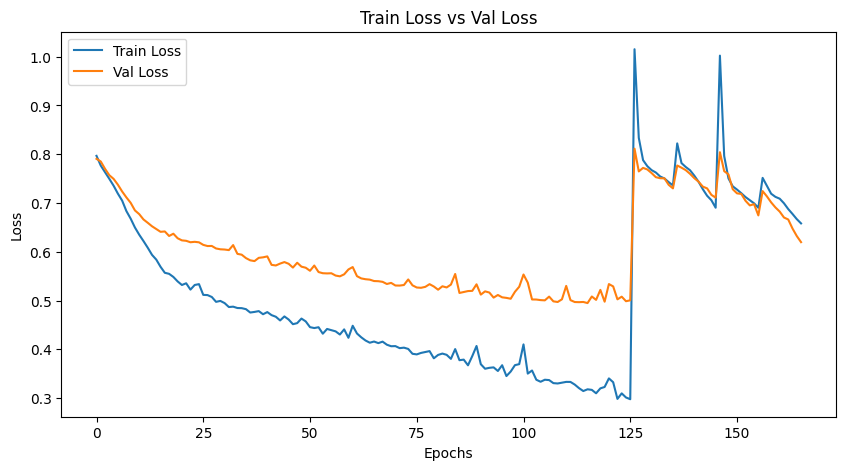

In [13]:
# Graficar Train Loss vs Val Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Val Loss')
plt.legend()
plt.show()

## NODE_GAM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['accuracy', 'f1', 'recall', 'roc_auc']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_anybal_{scoring}.pkl"
    joblib.dump(best_model, model_path)

WARNING! The apex is not installed so fp16 is not available.
Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\qhoptim\pyt\qhadam.py:133: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha) (Trig

Steps	Train Err	Val Metric (error_rate)
100	0.6055	0.197
200	0.4215	0.1667
300	0.3092	0.1212
400	0.2095	0.0909
500	0.2511	0.0758
600	0.0757	0.0455
700	0.0576	0.0455
800	0.121	0.0606
900	0.0482	0.0606
1000	0.0262	0.0455
1100	0.0255	0.0455
1200	0.1209	0.0606
1300	0.0737	0.0606
1400	0.0287	0.0606
1500	0.0063	0.0455
1600	0.0083	0.0455
1700	0.029	0.0303
1800	0.0776	0.0455
1900	0.0597	0.0455
2000	0.0109	0.0455
2100	0.0239	0.0606
2200	0.0485	0.0303
2300	0.0497	0.0303
2400	0.1502	0.0303
2500	0.029	0.0303
BREAK. There is no improvment for 500 steps
Total training time: 61.8 seconds
Best step:  1700
Best Val Metric:  0.030303030303030304
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for accuracy: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}
Best cross-validation accuracy: 0.9109979101358412
Fitting 5 folds for each of 10 candidates, t

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6221	0.1212
200	0.3658	0.1212
300	0.1518	0.0909
400	0.1335	0.0455
500	0.3239	0.0455
600	0.158	0.0303
700	0.1143	0.0455
800	0.1237	0.0758
900	0.0504	0.0606
1000	0.0725	0.0606
1100	0.0747	0.0455
1200	0.0208	0.0606
1300	0.0414	0.0303
1400	0.0689	0.0303
1500	0.0494	0.0303
1600	0.0525	0.0303
1700	0.0436	0.0303
1800	0.0465	0.0303
1900	0.0137	0.0303
2000	0.0947	0.0455
2100	0.015	0.0455
2200	0.1301	0.0455
2300	0.0308	0.0455
2400	0.0367	0.0455
2500	0.0221	0.0455
BREAK. There is no improvment for 500 steps
Total training time: 42.6 seconds
Best step:  600
Best Val Metric:  0.030303030303030304
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for f1: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}
Best cross-validation f1: 0.9045397657118697
Fitting 5 folds for each of 10 candidates, totalling 50

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6169	0.1515
200	0.4627	0.1061
300	0.3483	0.0909
400	0.3509	0.0606
500	0.1329	0.0758
600	0.1981	0.0303
700	0.0865	0.0606
800	0.0242	0.0455
900	0.1319	0.0606
1000	0.082	0.0606
1100	0.0513	0.0455
1200	0.1238	0.0152
1300	0.0204	0.0152
1400	0.029	0.0303
1500	0.0281	0.0152
1600	0.0423	0.0303
1700	0.0352	0.0303
1800	0.0212	0.0455
1900	0.0413	0.0152
2000	0.0627	0.0455
2100	0.0498	0.0303
2200	0.0519	0.0455
2300	0.0559	0.0455
2400	0.0036	0.0455
2500	0.0138	0.0455
BREAK. There is no improvment for 500 steps
Total training time: 43.8 seconds
Best step:  1200
Best Val Metric:  0.015151515151515152
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for recall: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}
Best cross-validation recall: 0.908925745884139
Fitting 5 folds for each of 10 candidates, tota

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Entrenando con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 3}
Steps	Train Err	Val Metric (error_rate)
100	0.6204	0.4091
200	0.7761	0.4394
300	0.7236	0.3939
400	0.5682	0.2727
500	0.4615	0.2576
600	0.6205	0.1667
700	0.5661	0.1364
800	0.5235	0.1364
900	0.3873	0.1212
1000	0.3855	0.1212
1100	0.2904	0.1364
1200	0.3017	0.1364
1300	0.2901	0.1061
1400	0.275	0.1061
1500	0.3357	0.0909
1600	0.2608	0.0758
1700	0.2778	0.0606
1800	0.4008	0.0606
1900	0.4576	0.0606
2000	0.3267	0.0758
2100	0.3658	0.0455
2200	0.3665	0.0455
2300	0.3715	0.0455
2400	0.1888	0.0455
2500	0.3307	0.0455
2600	0.2683	0.0455
BREAK. There is no improvment for 500 steps
Total training time: 42.8 seconds
Best step:  2100
Best Val Metric:  0.045454545454545456
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for roc_auc: {'output_dropout': 0.3, 'num_tr

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\unbal\\any")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 300,
    'num_layers': 2,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.4,
    'early_stopping_steps': 500,
    'depth': 3
}

# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")

WARNING! The apex is not installed so fp16 is not available.
Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (487) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "
c:\Users\ferro\AppData\Local\Programs\Py

Steps	Train Err	Val Metric (error_rate)
100	0.6483	0.2553
200	0.5229	0.234
300	0.2215	0.2128
400	0.1442	0.1915
500	0.1314	0.1489
600	0.0989	0.1915
700	0.0395	0.1064
800	0.049	0.0851
900	0.0134	0.0851
1000	0.0455	0.0851
1100	0.0627	0.0851
1200	0.0156	0.0851
1300	0.0514	0.0851
1400	0.0638	0.0851
1500	0.0078	0.0851
1600	0.0046	0.0851
1700	0.0046	0.1064
1800	0.0074	0.0851
1900	0.0231	0.0851
2000	0.0118	0.0851
2100	0.0611	0.0851
2200	0.0069	0.0851
2300	0.017	0.0851
2400	0.0054	0.1064
2500	0.0085	0.1064
BREAK. There is no improvment for 500 steps
Total training time: 50.5 seconds
Best step:  800
Best Val Metric:  0.0851063829787234
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 87.17948717948718%, F1-score: 87.19638963541402%, Test accuracy: 89.79591836734694%, Test F1-score: 89.83014589483592%
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001,

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5451	0.2766
200	0.3814	0.1489
300	0.2467	0.1064
400	0.2268	0.1064
500	0.1149	0.1064
600	0.0279	0.1277
700	0.0859	0.1277
800	0.0635	0.1277
900	0.058	0.1489
1000	0.0294	0.1489
1100	0.0296	0.1277
1200	0.033	0.1277
1300	0.0229	0.1489
1400	0.0158	0.1702
1500	0.0064	0.1489
1600	0.0698	0.1489
1700	0.0055	0.1489
1800	0.0208	0.1489
1900	0.0794	0.1277
2000	0.081	0.1489
2100	0.0104	0.1489
2200	0.0272	0.1277
2300	0.0324	0.1489
2400	0.0963	0.1277
2500	0.0103	0.1277
BREAK. There is no improvment for 500 steps
Total training time: 48.8 seconds
Best step:  300
Best Val Metric:  0.10638297872340426
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 85.8974358974359%, F1-score: 86.10428972810334%, Test accuracy: 89.79591836734694%, Test F1-score: 89.81739160310588%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001,

...

Steps	Train Err	Val Metric (error_rate)
100	0.5564	0.2128
200	0.6161	0.1915
300	0.3379	0.1489
400	0.2718	0.1915
500	0.1177	0.1702
600	0.036	0.1702
700	0.0897	0.1489
800	0.2139	0.1277
900	0.0222	0.0851
1000	0.0324	0.0851
1100	0.0397	0.0851
1200	0.0348	0.0851
1300	0.0102	0.0638
1400	0.0159	0.0851
1500	0.0259	0.0851
1600	0.0197	0.0638
1700	0.0303	0.0851
1800	0.009	0.0638
1900	0.0075	0.0851
2000	0.0273	0.0638
2100	0.041	0.0638
2200	0.008	0.0638
2300	0.0075	0.0638
2400	0.0147	0.0638
2500	0.0049	0.0638
BREAK. There is no improvment for 500 steps
Total training time: 49.8 seconds
Best step:  1300
Best Val Metric:  0.06382978723404255
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 96.15384615384616%, F1-score: 96.15447843295945%, Test accuracy: 90.81632653061224%, Test F1-score: 90.8423644581218%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001,

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (312). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5034	0.1489
200	0.3385	0.0851
300	0.227	0.1064
400	0.2172	0.1277
500	0.102	0.0851
600	0.0632	0.1064
700	0.1029	0.1064
800	0.0785	0.1064
900	0.0906	0.1064
1000	0.034	0.1064
1100	0.1385	0.0851
1200	0.0489	0.1064
1300	0.0169	0.1064
1400	0.0458	0.1064
1500	0.0519	0.1064
1600	0.0264	0.0851
1700	0.0405	0.0851
1800	0.0075	0.0851
1900	0.0298	0.0851
2000	0.0322	0.0851
2100	0.0274	0.0851
2200	0.0177	0.0851
2300	0.0339	0.0851
2400	0.0662	0.0851
2500	0.005	0.0851
BREAK. There is no improvment for 500 steps
Total training time: 49.3 seconds
Best step:  200
Best Val Metric:  0.0851063829787234
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 87.01298701298701%, F1-score: 87.07482993197277%, Test accuracy: 86.73469387755102%, Test F1-score: 86.77230421728703%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6221	0.2034
200	0.3979	0.1356
300	0.2884	0.1186
400	0.4389	0.1017
500	0.1154	0.1017
600	0.1321	0.0847
700	0.0613	0.0847
800	0.0413	0.0678
900	0.0518	0.0508
1000	0.0542	0.0678
1100	0.0369	0.0847
1200	0.036	0.0847
1300	0.0295	0.0847
1400	0.057	0.0847
1500	0.1059	0.0678
1600	0.0127	0.0847
1700	0.0399	0.0847
1800	0.025	0.1017
1900	0.0012	0.1017
2000	0.0113	0.1017
2100	0.013	0.1017
2200	0.013	0.0847
2300	0.0676	0.0847
2400	0.0088	0.1017
2500	0.0178	0.1186
BREAK. There is no improvment for 500 steps
Total training time: 49.6 seconds
Best step:  900
Best Val Metric:  0.05084745762711865
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\unbal\any\best_model_fold_4.pth


In [15]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 89.97 ± 4.11%
F1-score: 90.01 ± 4.04%
Precisión (Precision): 90.48 ± 3.92%
Recall: 89.97 ± 4.11%

Métricas del Conjunto de Prueba:
Precisión: 89.80 ± 1.71%
F1-score: 89.82 ± 1.70%
Precisión (Precision): 89.99 ± 1.65%
Recall: 89.80 ± 1.71%


# UNbalanced PCA

In [16]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

In [17]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train)
X_train_pca= pca.transform(X_train)
X_test_pca=pca.transform(X_test)

In [18]:
X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)


## KAN

In [19]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [20]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\pca\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")




Fold 1


100%|██████████| 10/10 [00:00<00:00, 42.49it/s, accuracy=0.435, loss=0.818, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\pca\best_model.pth con val_loss: 0.7921985586484274
Epoch 1, Train Loss: 0.7847393214702606, Val Loss: 0.7921985586484274, Val Accuracy: 0.5178571542104086


100%|██████████| 10/10 [00:00<00:00, 37.63it/s, accuracy=0.522, loss=0.79, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\pca\best_model.pth con val_loss: 0.7838494181632996
Epoch 2, Train Loss: 0.7763606011867523, Val Loss: 0.7838494181632996, Val Accuracy: 0.5178571542104086


...

Epoch 8, Train Loss: 0.7138937652111054, Val Loss: 0.70378311475118, Val Accuracy: 0.6570512851079305


100%|██████████| 10/10 [00:00<00:00, 42.26it/s, accuracy=0.667, loss=0.656, lr=0.0001]


Epoch 9, Train Loss: 0.6983569502830506, Val Loss: 0.6896088322003683, Val Accuracy: 0.6466346184412638


100%|██████████| 10/10 [00:00<00:00, 40.17it/s, accuracy=0.917, loss=0.627, lr=0.0001]


Epoch 10, Train Loss: 0.6851691782474518, Val Loss: 0.6736399332682291, Val Accuracy: 0.6674679517745972
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 72.44897959183673%, F1-score: 72.0525405878028%, Precision: 72.42337795333187%, Recall: 72.44897959183673%


In [21]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 72.10 ± 7.40%
F1-score: 71.75 ± 8.01%
Precisión (Precision): 73.47 ± 6.53%
Recall: 72.10 ± 7.40%

Métricas del Conjunto de Prueba:
Precisión: 74.69 ± 3.19%
F1-score: 74.49 ± 3.22%
Precisión (Precision): 74.94 ± 3.44%
Recall: 74.69 ± 3.19%


## NODE_GAM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['accuracy', 'f1', 'recall', 'roc_auc']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_pcabal_{scoring}.pkl"
    joblib.dump(best_model, model_path)

Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6366	0.3788
200	0.6587	0.3182
300	0.6697	0.2424
400	0.4948	0.1818
500	0.4487	0.1667
600	0.5041	0.1515
700	0.479	0.0909
800	0.4617	0.0909
900	0.3254	0.1061
1000	0.2682	0.1212
1100	0.3843	0.1212
1200	0.5129	0.1364
1300	0.4505	0.1364
1400	0.6309	0.1515
1500	0.3145	0.1515
1600	0.2838	0.1515
1700	0.3648	0.1515
1800	0.3157	0.1515
1900	0.2906	0.1364
2000	0.3313	0.1364
2100	0.2705	0.1515
2200	0.3346	0.1515
2300	0.2524	0.1061
2400	0.2709	0.1212
2500	0.4007	0.1212
BREAK. There is no improvment for 500 steps
Total training time: 64.3 seconds
Best step:  700
Best Val Metric:  0.09090909090909091
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for accuracy: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Best cross-validation accuracy: 0.8492685475444096
Fitting 5 folds for each of 10 candidates,

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7247	0.2273
200	0.4829	0.1212
300	0.3877	0.1364
400	0.475	0.1515
500	0.2033	0.1818
600	0.2748	0.1515
700	0.1484	0.1667
800	0.1349	0.1667
900	0.2986	0.1364
1000	0.1923	0.1364
1100	0.4275	0.1364
1200	0.2744	0.1212
1300	0.3357	0.1212
1400	0.2191	0.1212
1500	0.1743	0.0909
1600	0.2387	0.0909
1700	0.3884	0.0909
1800	0.255	0.1212
1900	0.2165	0.1061
2000	0.2349	0.1061
2100	0.1592	0.1061
2200	0.1567	0.1061
2300	0.2375	0.0909
2400	0.1395	0.1061
2500	0.1536	0.1061
BREAK. There is no improvment for 500 steps
Total training time: 62.6 seconds
Best step:  1500
Best Val Metric:  0.09090909090909091
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for f1: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}
Best cross-validation f1: 0.8347178785646638
Fitting 5 folds for each of 10 candidates, totalling 50

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5609	0.3485
200	0.5944	0.1818
300	0.4215	0.1212
400	0.351	0.1364
500	0.2404	0.1364
600	0.3142	0.1667
700	0.4301	0.1667
800	0.3408	0.1818
900	0.3107	0.1667
1000	0.3414	0.1515
1100	0.2137	0.1515
1200	0.2803	0.1515
1300	0.2649	0.1515
1400	0.3156	0.1364
1500	0.3462	0.1515
1600	0.3909	0.1515
1700	0.1757	0.1515
1800	0.1844	0.1667
1900	0.3412	0.1515
2000	0.2357	0.1364
2100	0.2736	0.1667
2200	0.1966	0.1515
2300	0.2126	0.1364
2400	0.1999	0.1364
2500	0.1452	0.1364
BREAK. There is no improvment for 500 steps
Total training time: 67.4 seconds
Best step:  300
Best Val Metric:  0.12121212121212122
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for recall: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Best cross-validation recall: 0.881865412432127
Fitting 5 folds for each of 10 candidates, total

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Entrenando con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Steps	Train Err	Val Metric (error_rate)
100	0.6807	0.3485
200	0.5463	0.2424
300	0.3891	0.1818
400	0.3859	0.1515
500	0.3904	0.1364
600	0.3324	0.1212
700	0.3859	0.1364
800	0.4442	0.1667
900	0.2934	0.1364
1000	0.2898	0.1515
1100	0.3866	0.1515
1200	0.2889	0.1515
1300	0.2992	0.1515
1400	0.2963	0.1515
1500	0.3174	0.1515
1600	0.266	0.1212
1700	0.2987	0.1515
1800	0.2109	0.1667
1900	0.2426	0.1515
2000	0.1722	0.1667
2100	0.1904	0.1364
2200	0.3424	0.1515
2300	0.2083	0.1667
2400	0.1118	0.1515
2500	0.2691	0.1515
BREAK. There is no improvment for 500 steps
Total training time: 42.4 seconds
Best step:  600
Best Val Metric:  0.12121212121212122
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for roc_auc: {'output_dropout': 0.2, 'num_trees': 100, 'num_layers

In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\unbal\\PCA")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 300,
    'num_layers': 2,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (487) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Steps	Train Err	Val Metric (error_rate)
100	0.6094	0.1915
200	0.4278	0.234
300	0.5833	0.2128
400	0.3616	0.1915
500	0.305	0.1915
600	0.2565	0.1702
700	0.204	0.1489
800	0.1347	0.1702
900	0.2683	0.1702
1000	0.3978	0.1702
1100	0.1408	0.1702
1200	0.2497	0.1702
1300	0.2348	0.1915
1400	0.2203	0.1915
1500	0.3247	0.1915
1600	0.2063	0.1702
1700	0.1436	0.1702
1800	0.1397	0.1915
1900	0.1759	0.1702
2000	0.0805	0.1915
2100	0.1805	0.1915
2200	0.2618	0.1915
2300	0.0824	0.1915
2400	0.1687	0.1915
2500	0.1978	0.2128
BREAK. There is no improvment for 500 steps
Total training time: 48.7 seconds
Best step:  700
Best Val Metric:  0.14893617021276595
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 84.61538461538461%, F1-score: 84.615

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6629	0.383
200	0.444	0.2766
300	0.3071	0.2766
400	0.1964	0.234
500	0.2118	0.2128
600	0.1529	0.2766
700	0.2732	0.234
800	0.2378	0.2128
900	0.1322	0.2553
1000	0.1381	0.234
1100	0.1299	0.234
1200	0.1659	0.234
1300	0.1159	0.234
1400	0.2524	0.234
1500	0.2226	0.234
1600	0.1223	0.234
1700	0.142	0.234
1800	0.0096	0.234
1900	0.0902	0.2128
2000	0.0637	0.1915
2100	0.074	0.1915
2200	0.2008	0.234
2300	0.1193	0.1915
2400	0.1833	0.1915
2500	0.0934	0.1915
BREAK. There is no improvment for 500 steps
Total training time: 48.7 seconds
Best step:  2000
Best Val Metric:  0.19148936170212766
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 87.17948717948718%, F1-score: 87.2697089445858%, Test accuracy: 87.75510204081633%, Test F1-score: 87.75510204081633%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropo

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.6786	0.3404
200	0.4247	0.1915
300	0.3216	0.1277
400	0.2448	0.1277
500	0.2656	0.1277
600	0.5896	0.1064
700	0.2018	0.1489
800	0.128	0.1915
900	0.4148	0.1489
1000	0.2794	0.1489
1100	0.1701	0.1702
1200	0.2521	0.1489
1300	0.1242	0.1489
1400	0.5218	0.1489
1500	0.2083	0.1702
1600	0.1715	0.1915
1700	0.2239	0.1702
1800	0.4855	0.1915
1900	0.1326	0.1489
2000	0.1825	0.1702
2100	0.2594	0.1702
2200	0.1157	0.1702
2300	0.0967	0.1489
2400	0.1062	0.1702
2500	0.0972	0.1702
BREAK. There is no improvment for 500 steps
Total training time: 49.1 seconds
Best step:  600
Best Val Metric:  0.10638297872340426
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 85.8974358974359%, F1-score: 85.86261475150366%, Test accuracy: 86.73469387755102%, Test F1-score: 86.75008124097472%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.00

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (312). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6912	0.1277
200	0.5092	0.1277
300	0.3088	0.2128
400	0.1857	0.234
500	0.1919	0.234
600	0.1363	0.2553
700	0.4094	0.234
800	0.165	0.2128
900	0.4025	0.2128
1000	0.2271	0.234
1100	0.2692	0.2553
1200	0.2228	0.2553
1300	0.1215	0.234
1400	0.0665	0.2128
1500	0.0791	0.234
1600	0.2146	0.234
1700	0.1839	0.2128
1800	0.1405	0.2128
1900	0.1531	0.2128
2000	0.4923	0.2128
2100	0.2202	0.2128
2200	0.1254	0.2128
2300	0.0793	0.2128
2400	0.2653	0.2128
2500	0.1805	0.2128
BREAK. There is no improvment for 500 steps
Total training time: 48.7 seconds
Best step:  100
Best Val Metric:  0.1276595744680851
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 77.92207792207793%, F1-score: 76.63526460462758%, Test accuracy: 77.55102040816327%, Test F1-score: 76.41075477810172%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.608	0.3729
200	0.3828	0.1695
300	0.292	0.1017
400	0.3641	0.1356
500	0.3373	0.1017
600	0.4543	0.1017
700	0.2927	0.0847
800	0.2285	0.1017
900	0.175	0.1017
1000	0.2869	0.1017
1100	0.1028	0.1525
1200	0.1508	0.1695
1300	0.4137	0.1356
1400	0.2166	0.1356
1500	0.2483	0.1525
1600	0.1951	0.1186
1700	0.1715	0.1356
1800	0.1463	0.1356
1900	0.1356	0.1356
2000	0.1817	0.1186
2100	0.1296	0.1356
2200	0.0862	0.1356
2300	0.2308	0.1356
2400	0.2694	0.1525
2500	0.2184	0.1356
BREAK. There is no improvment for 500 steps
Total training time: 49.0 seconds
Best step:  700
Best Val Metric:  0.0847457627118644
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\unbal\PCA\best_model_fold_2.pth


In [23]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 83.79 ± 3.20%
F1-score: 83.54 ± 3.69%
Precisión (Precision): 84.72 ± 2.46%
Recall: 83.79 ± 3.20%

Métricas del Conjunto de Prueba:
Precisión: 83.88 ± 3.79%
F1-score: 83.67 ± 4.18%
Precisión (Precision): 84.45 ± 2.98%
Recall: 83.88 ± 3.79%


# Balanced scaler

In [24]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

In [25]:
scaler = StandardScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [26]:
X_train_unbalance= torch.tensor(X_train_scaler, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_scaler, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [27]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [28]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\scaler\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")




Fold 1


100%|██████████| 10/10 [00:00<00:00, 41.53it/s, accuracy=0.435, loss=0.807, lr=0.0001]
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\scaler\best_model.pth con val_loss: 0.7896469235420227
Epoch 1, Train Loss: 0.7800149500370026, Val Loss: 0.7896469235420227, Val Accuracy: 0.5178571542104086


100%|██████████| 10/10 [00:00<00:00, 41.39it/s, accuracy=0.478, loss=0.798, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\scaler\best_model.pth con val_loss: 0.7891655961672465
Epoch 2, Train Loss: 0.7792106926441192, Val Loss: 0.7891655961672465, Val Accuracy: 0.5178571542104086


...

Epoch 8, Train Loss: 0.7690008044242859, Val Loss: 0.7542687853177389, Val Accuracy: 0.6258012851079305


100%|██████████| 10/10 [00:00<00:00, 40.87it/s, accuracy=0.542, loss=0.773, lr=0.0001]


Epoch 9, Train Loss: 0.7647837340831757, Val Loss: 0.7493801315625509, Val Accuracy: 0.6258012851079305


100%|██████████| 10/10 [00:00<00:00, 36.45it/s, accuracy=0.625, loss=0.742, lr=0.0001]


Epoch 10, Train Loss: 0.7583703756332397, Val Loss: 0.743169903755188, Val Accuracy: 0.6258012851079305
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 85.71428571428571%, F1-score: 85.71428571428571%, Precision: 88.32376925400182%, Recall: 85.71428571428571%


In [29]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 75.44 ± 13.10%
F1-score: 73.75 ± 16.86%
Precisión (Precision): 78.27 ± 13.55%
Recall: 75.44 ± 13.10%

Métricas del Conjunto de Prueba:
Precisión: 82.04 ± 5.65%
F1-score: 81.93 ± 5.80%
Precisión (Precision): 84.54 ± 4.41%
Recall: 82.04 ± 5.65%


## NODE_GAM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['accuracy', 'f1', 'recall', 'roc_auc']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_scabal_{scoring}.pkl"
    joblib.dump(best_model, model_path)

Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5397	0.1212
200	0.457	0.0758
300	0.1754	0.0758
400	0.2378	0.0758
500	0.0774	0.0909
600	0.0381	0.0455
700	0.0621	0.0758
800	0.0236	0.0606
900	0.1023	0.0606
1000	0.0409	0.0303
1100	0.0332	0.0303
1200	0.0011	0.0455
1300	0.0055	0.0303
1400	0.0146	0.0303
1500	0.0374	0.0455
1600	0.03	0.0455
1700	0.0103	0.0303
1800	0.0477	0.0455
1900	0.0074	0.0303
2000	0.0141	0.0455
2100	0.035	0.0303
2200	0.0499	0.0455
2300	0.0202	0.0455
2400	0.0035	0.0455
2500	0.0068	0.0455
BREAK. There is no improvment for 500 steps
Total training time: 61.6 seconds
Best step:  1000
Best Val Metric:  0.030303030303030304
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for accuracy: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}
Best cross-validation accuracy: 0.9155433646812956
Fitting 5 folds for each of 10 candidates, t

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6376	0.303
200	0.5502	0.2273
300	0.5878	0.197
400	0.177	0.1515
500	0.1766	0.1212
600	0.1028	0.0606
700	0.1181	0.0909
800	0.153	0.0909
900	0.1071	0.0909
1000	0.0699	0.0909
1100	0.1932	0.0303
1200	0.1425	0.0303
1300	0.0664	0.0303
1400	0.0871	0.0152
1500	0.1265	0.0303
1600	0.1331	0.0152
1700	0.0822	0.0152
1800	0.0682	0.0152
1900	0.0727	0.0152
2000	0.033	0.0758
2100	0.1426	0.0455
2200	0.107	0.0152
2300	0.2374	0.0
2400	0.1299	0.0303
2500	0.0203	0.0303
2600	0.1114	0.0303
2700	0.1319	0.0152
2800	0.0772	0.0152
BREAK. There is no improvment for 500 steps
Total training time: 48.7 seconds
Best step:  2300
Best Val Metric:  0.0
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for f1: {'output_dropout': 0.3, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Best cross-validation f1: 0.8989183159062677
Fitting 5 folds for e

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5757	0.197
200	0.3246	0.1212
300	0.2725	0.1061
400	0.3772	0.0909
500	0.0783	0.0455
600	0.1312	0.0455
700	0.1329	0.0455
800	0.0375	0.0606
900	0.0577	0.0606
1000	0.0473	0.0606
1100	0.0645	0.0606
1200	0.0993	0.0606
1300	0.0496	0.0455
1400	0.0261	0.0606
1500	0.0135	0.0455
1600	0.0454	0.0303
1700	0.0381	0.0455
1800	0.0682	0.0606
1900	0.0384	0.0455
2000	0.0246	0.0455
2100	0.014	0.0455
2200	0.0105	0.0303
2300	0.0037	0.0303
2400	0.0419	0.0455
2500	0.0013	0.0455
BREAK. There is no improvment for 500 steps
Total training time: 66.4 seconds
Best step:  1600
Best Val Metric:  0.030303030303030304
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for recall: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Best cross-validation recall: 0.9150350572301793
Fitting 5 folds for each of 10 candidates, tot

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Entrenando con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 3}
Steps	Train Err	Val Metric (error_rate)
100	0.6199	0.1515
200	0.3942	0.1061
300	0.1884	0.0606
400	0.1971	0.0606
500	0.1797	0.0606
600	0.0605	0.0606
700	0.1783	0.0606
800	0.171	0.0909
900	0.1704	0.0606
1000	0.0748	0.0606
1100	0.0497	0.0606
1200	0.0444	0.0152
1300	0.0481	0.0303
1400	0.064	0.0303
1500	0.0644	0.0152
1600	0.0635	0.0303
1700	0.0341	0.0303
1800	0.0981	0.0152
1900	0.1004	0.0
2000	0.0942	0.0
2100	0.0673	0.0455
2200	0.0352	0.0303
2300	0.0926	0.0455
2400	0.0669	0.0303
2500	0.1205	0.0303
BREAK. There is no improvment for 500 steps
Total training time: 64.4 seconds
Best step:  1900
Best Val Metric:  0.0
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for roc_auc: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps

In [30]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\unbal\\scaler")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 200,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (487) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5817	0.2553
200	0.3019	0.234
300	0.1838	0.1915
400	0.2141	0.1489
500	0.0655	0.1489
600	0.0841	0.1277
700	0.1943	0.1277
800	0.0327	0.1489
900	0.0305	0.1277
1000	0.0801	0.1277
1100	0.07	0.1277
1200	0.048	0.1064
1300	0.0452	0.1277
1400	0.0216	0.1277
1500	0.0228	0.1277
1600	0.0479	0.1277
1700	0.0076	0.1064
1800	0.001	0.0851
1900	0.0919	0.0638
2000	0.0423	0.0638
2100	0.018	0.0851
2200	0.0273	0.1064
2300	0.015	0.1064
2400	0.0096	0.1064
2500	0.0673	0.1064
BREAK. There is no improvment for 500 steps
Total training time: 78.1 seconds
Best step:  1900
Best Val Metric:  0.06382978723404255
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 85.8974358974359%, F1-score: 85.90907359681084%, Test accuracy: 89.79591836734694%, Test F1-score: 89.81739160310588%
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'l

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.4346	0.2128
200	0.4227	0.1489
300	0.2263	0.1064
400	0.1193	0.0851
500	0.1824	0.0851
600	0.0657	0.1064
700	0.1151	0.1277
800	0.035	0.1277
900	0.0099	0.1489
1000	0.0206	0.1277
1100	0.0223	0.1277
1200	0.0214	0.0638
1300	0.0285	0.0638
1400	0.0118	0.1064
1500	0.0398	0.0851
1600	0.0074	0.0851
1700	0.0285	0.0851
1800	0.0033	0.1064
1900	0.0113	0.1277
2000	0.0029	0.1064
2100	0.0502	0.1064
2200	0.0039	0.1064
2300	0.0069	0.1064
2400	0.0224	0.1064
2500	0.025	0.0851
BREAK. There is no improvment for 500 steps
Total training time: 75.6 seconds
Best step:  1200
Best Val Metric:  0.06382978723404255
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 94.87179487179486%, F1-score: 94.87179487179486%, Test accuracy: 87.75510204081633%, Test F1-score: 87.75510204081633%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (312). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5052	0.234
200	0.3098	0.1702
300	0.2304	0.0851
400	0.1478	0.0851
500	0.1753	0.0851
600	0.0254	0.0851
700	0.1249	0.0851
800	0.0679	0.0638
900	0.1622	0.0851
1000	0.025	0.0851
1100	0.047	0.0851
1200	0.0452	0.0851
1300	0.0394	0.0851
1400	0.0416	0.0851
1500	0.0091	0.0638
1600	0.021	0.0851
1700	0.031	0.0851
1800	0.0997	0.1064
1900	0.0274	0.0638
2000	0.0257	0.0851
2100	0.0256	0.1064
2200	0.0418	0.0851
2300	0.0223	0.0851
2400	0.0153	0.0851
2500	0.0019	0.0851
BREAK. There is no improvment for 500 steps
Total training time: 78.3 seconds
Best step:  800
Best Val Metric:  0.06382978723404255
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 96.1038961038961%, F1-score: 96.07535321821035%, Test accuracy: 92.85714285714286%, Test F1-score: 92.86542836052486%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.574	0.1695
200	0.4629	0.1186
300	0.2118	0.1017
400	0.1766	0.0847
500	0.1062	0.0847
600	0.0391	0.0847
700	0.0821	0.0678
800	0.0224	0.0678
900	0.0364	0.0678
1000	0.0229	0.0847
1100	0.0359	0.0678
1200	0.0157	0.1017
1300	0.0731	0.1017
1400	0.0548	0.1017
1500	0.0343	0.1017
1600	0.0304	0.1017
1700	0.0337	0.1017
1800	0.0318	0.1017
1900	0.0079	0.0847
2000	0.0074	0.1017
2100	0.0365	0.1017
2200	0.0067	0.1356
2300	0.0131	0.1186
2400	0.0236	0.1186
2500	0.0105	0.1356
BREAK. There is no improvment for 500 steps
Total training time: 77.1 seconds
Best step:  700
Best Val Metric:  0.06779661016949153
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\unbal\scaler\best_model_fold_5.pth


In [31]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 90.50 ± 4.62%
F1-score: 90.54 ± 4.54%
Precisión (Precision): 90.92 ± 4.33%
Recall: 90.50 ± 4.62%

Métricas del Conjunto de Prueba:
Precisión: 90.41 ± 1.66%
F1-score: 90.42 ± 1.66%
Precisión (Precision): 90.46 ± 1.66%
Recall: 90.41 ± 1.66%


# BALANCED PCA_SCALER

In [32]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

In [33]:
scaler = StandardScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [34]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_scaler)
X_train_pca= pca.transform(X_train_scaler)
X_test_pca=pca.transform(X_test_scaler)

In [35]:
X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [36]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [37]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\pca_scaler\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")
   

Fold 1


100%|██████████| 10/10 [00:00<00:00, 41.79it/s, accuracy=0.739, loss=0.745, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\pca_scaler\best_model.pth con val_loss: 0.7891618013381958
Epoch 1, Train Loss: 0.7779800891876221, Val Loss: 0.7891618013381958, Val Accuracy: 0.5178571542104086


100%|██████████| 10/10 [00:00<00:00, 38.81it/s, accuracy=0.609, loss=0.769, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\pca_scaler\best_model.pth con val_loss: 0.7884872754414877
Epoch 2, Train Loss: 0.7779741942882538, Val Loss: 0.7884872754414877, Val Accuracy: 0.5178571542104086


...

Epoch 8, Train Loss: 0.7731801509857178, Val Loss: 0.7598951061566671, Val Accuracy: 0.6258012851079305


100%|██████████| 10/10 [00:00<00:00, 39.60it/s, accuracy=0.5, loss=0.78, lr=0.0001]  


Epoch 9, Train Loss: 0.7703149080276489, Val Loss: 0.7572086254755656, Val Accuracy: 0.6258012851079305


100%|██████████| 10/10 [00:00<00:00, 40.51it/s, accuracy=0.583, loss=0.753, lr=0.0001]


Epoch 10, Train Loss: 0.7660119712352753, Val Loss: 0.7536234259605408, Val Accuracy: 0.6258012851079305
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 67.3469387755102%, F1-score: 66.97836325165517%, Precision: 71.39963650502293%, Recall: 67.3469387755102%


In [38]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 81.60 ± 9.09%
F1-score: 81.52 ± 9.27%
Precisión (Precision): 83.32 ± 8.12%
Recall: 81.60 ± 9.09%

Métricas del Conjunto de Prueba:
Precisión: 80.00 ± 6.51%
F1-score: 79.95 ± 6.65%
Precisión (Precision): 81.13 ± 5.02%
Recall: 80.00 ± 6.51%


## NODE_GAM

In [39]:

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\unbal\\PCA_scaler")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 300,
    'num_layers': 2,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.4,
    'early_stopping_steps': 500,
    'depth': 3
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")



c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (487) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 3}
Steps	Train Err	Val Metric (error_rate)
100	0.6667	0.4468
200	0.492	0.2128
300	0.4326	0.1702
400	0.4161	0.1489
500	0.1116	0.1064
600	0.4203	0.1064
700	0.0762	0.0638
800	0.2991	0.1064
900	0.0257	0.0638
1000	0.2072	0.0638
1100	0.0635	0.0426
1200	0.047	0.0426
1300	0.0434	0.0638
1400	0.0819	0.0426
1500	0.0313	0.0426
1600	0.033	0.0426
1700	0.0483	0.0426
1800	0.006	0.0638
1900	0.071	0.0638
2000	0.0408	0.0851
2100	0.1042	0.0638
2200	0.0905	0.0638
2300	0.0419	0.0638
2400	0.0202	0.0851
2500	0.0897	0.0851
BREAK. There is no improvment for 500 steps
Total training time: 49.2 seconds
Best step:  1100
Best Val Metric:  0.0425531914893617
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 89.74358974358975%, F1-score: 89.75708

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6221	0.4468
200	0.3913	0.3191
300	0.2982	0.234
400	0.2252	0.1915
500	0.086	0.1702
600	0.1784	0.1277
700	0.0539	0.1277
800	0.0287	0.1277
900	0.0628	0.1277
1000	0.0408	0.1489
1100	0.0468	0.1489
1200	0.013	0.1489
1300	0.0343	0.1489
1400	0.0455	0.1489
1500	0.0344	0.1489
1600	0.0449	0.1277
1700	0.0235	0.1277
1800	0.008	0.1489
1900	0.0191	0.1489
2000	0.0417	0.1277
2100	0.1246	0.1277
2200	0.0021	0.1277
2300	0.0751	0.1277
2400	0.0558	0.1277
2500	0.0368	0.1277
BREAK. There is no improvment for 500 steps
Total training time: 49.0 seconds
Best step:  600
Best Val Metric:  0.1276595744680851
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 89.74358974358975%, F1-score: 89.91253541699663%, Test accuracy: 91.83673469387756%, Test F1-score: 91.83673469387756%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.6487	0.1915
200	0.532	0.0851
300	0.299	0.0851
400	0.1705	0.0851
500	0.1808	0.0851
600	0.1197	0.0851
700	0.3545	0.0851
800	0.2375	0.0638
900	0.1585	0.0638
1000	0.0522	0.0638
1100	0.0925	0.0638
1200	0.1902	0.0638
1300	0.1402	0.0638
1400	0.1085	0.0638
1500	0.1006	0.0638
1600	0.0764	0.0638
1700	0.0896	0.0426
1800	0.0337	0.0638
1900	0.1243	0.0638
2000	0.0853	0.0851
2100	0.1233	0.0426
2200	0.2409	0.0426
2300	0.015	0.0213
2400	0.0564	0.0426
2500	0.139	0.0426
2600	0.0255	0.0426
2700	0.0281	0.0426
2800	0.0519	0.0426
BREAK. There is no improvment for 500 steps
Total training time: 53.6 seconds
Best step:  2300
Best Val Metric:  0.02127659574468085
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 89.74358974358975%, F1-score: 89.73009446693658%, Test accuracy: 88.77551020408163%, Test F1-score: 88.7216556310124%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 2, 'l

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (312). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.8703	0.1702
200	0.4987	0.0851
300	0.3271	0.1702
400	0.2398	0.1702
500	0.1168	0.1064
600	0.1388	0.1277
700	0.1304	0.1277
800	0.0483	0.1277
900	0.0991	0.1064
1000	0.0287	0.1064
1100	0.0452	0.1064
1200	0.0374	0.1064
1300	0.0236	0.1064
1400	0.0349	0.1277
1500	0.0427	0.1064
1600	0.044	0.1064
1700	0.0335	0.1064
1800	0.0195	0.1064
1900	0.0661	0.0851
2000	0.0161	0.0851
2100	0.0358	0.1064
2200	0.0479	0.0851
2300	0.0396	0.0851
2400	0.0573	0.0851
2500	0.046	0.0851
BREAK. There is no improvment for 500 steps
Total training time: 49.4 seconds
Best step:  200
Best Val Metric:  0.0851063829787234
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 89.6103896103896%, F1-score: 89.56349206349206%, Test accuracy: 83.6734693877551%, Test F1-score: 83.6734693877551%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6684	0.322
200	0.4452	0.2542
300	0.3023	0.1864
400	0.3278	0.1356
500	0.2214	0.1017
600	0.1838	0.1186
700	0.0738	0.1356
800	0.2102	0.1356
900	0.0662	0.0847
1000	0.3567	0.1017
1100	0.2565	0.1017
1200	0.0602	0.1186
1300	0.045	0.0847
1400	0.0246	0.1017
1500	0.1469	0.1186
1600	0.1628	0.1356
1700	0.0139	0.1186
1800	0.0476	0.1017
1900	0.0562	0.1356
2000	0.1119	0.1525
2100	0.0279	0.1525
2200	0.0504	0.1525
2300	0.0368	0.1695
2400	0.0575	0.1695
2500	0.0607	0.1695
BREAK. There is no improvment for 500 steps
Total training time: 48.4 seconds
Best step:  900
Best Val Metric:  0.0847457627118644
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\unbal\PCA_scaler\best_model_fold_3.pth


In [40]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 89.97 ± 0.53%
F1-score: 89.98 ± 0.50%
Precisión (Precision): 90.48 ± 0.60%
Recall: 89.97 ± 0.53%

Métricas del Conjunto de Prueba:
Precisión: 88.78 ± 2.74%
F1-score: 88.77 ± 2.74%
Precisión (Precision): 88.94 ± 2.81%
Recall: 88.78 ± 2.74%


# Balanced Robustscaler

In [41]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

In [42]:
scaler = RobustScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [43]:
X_train_unbalance= torch.tensor(X_train_scaler, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_scaler, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)


## KAN

In [44]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [45]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Roscaler\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")




Fold 1


100%|██████████| 10/10 [00:00<00:00, 35.91it/s, accuracy=0.652, loss=0.762, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\Roscaler\best_model.pth con val_loss: 0.7889143427213033
Epoch 1, Train Loss: 0.7783761382102966, Val Loss: 0.7889143427213033, Val Accuracy: 0.5178571542104086


100%|██████████| 10/10 [00:00<00:00, 45.87it/s, accuracy=0.522, loss=0.788, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\Roscaler\best_model.pth con val_loss: 0.7884848117828369
Epoch 2, Train Loss: 0.778431236743927, Val Loss: 0.7884848117828369, Val Accuracy: 0.5178571542104086


...

Epoch 8, Train Loss: 0.7750607073307038, Val Loss: 0.7608999808629354, Val Accuracy: 0.6258012851079305


100%|██████████| 10/10 [00:00<00:00, 39.49it/s, accuracy=0.583, loss=0.771, lr=0.0001]


Epoch 9, Train Loss: 0.7722969889640808, Val Loss: 0.7582251230875651, Val Accuracy: 0.6258012851079305


100%|██████████| 10/10 [00:00<00:00, 40.25it/s, accuracy=0.708, loss=0.739, lr=0.0001]


Epoch 10, Train Loss: 0.7682568371295929, Val Loss: 0.7546069025993347, Val Accuracy: 0.6258012851079305
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 85.71428571428571%, F1-score: 85.76196436021218%, Precision: 86.95393050837356%, Recall: 85.71428571428571%


In [46]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 79.19 ± 10.33%
F1-score: 78.56 ± 11.64%
Precisión (Precision): 82.38 ± 6.74%
Recall: 79.19 ± 10.33%

Métricas del Conjunto de Prueba:
Precisión: 81.02 ± 8.67%
F1-score: 80.62 ± 9.27%
Precisión (Precision): 84.05 ± 5.23%
Recall: 81.02 ± 8.67%


## NODE_GAM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['accuracy']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_scabal_{scoring}.pkl"
    joblib.dump(best_model, model_path)

Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (386). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.8411	0.4655
200	0.6545	0.3621
300	0.5433	0.2931
400	0.6292	0.2241
500	0.3484	0.2241
600	0.4341	0.1724
700	0.4246	0.1897
800	0.373	0.1724
900	0.2875	0.1552
1000	0.2353	0.1552
1100	0.1653	0.1552
1200	0.3304	0.1379
1300	0.161	0.1552
1400	0.2464	0.1552
1500	0.2368	0.1552
1600	0.1879	0.1552
1700	0.1492	0.1724
1800	0.2798	0.1552
1900	0.1468	0.1207
2000	0.1328	0.1207
2100	0.1763	0.1034
2200	0.1518	0.0862
2300	0.1252	0.1034
2400	0.2377	0.1034
2500	0.2879	0.1034
2600	0.446	0.1034
2700	0.2406	0.1034
BREAK. There is no improvment for 500 steps
Total training time: 74.7 seconds
Best step:  2200
Best Val Metric:  0.08620689655172414
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for accuracy: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 3}
Best cross-validation accuracy: 0.8991674991674993


In [47]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\unbal\\roscaler")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 300,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.4,
    'early_stopping_steps': 500,
    'depth': 4
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (487) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5978	0.2979
200	0.6266	0.1915
300	0.199	0.1702
400	0.3398	0.1702
500	0.0962	0.1489
600	0.0825	0.1064
700	0.0392	0.1064
800	0.0101	0.1064
900	0.0634	0.1064
1000	0.0184	0.1064
1100	0.0041	0.1277
1200	0.0143	0.1064
1300	0.0138	0.0851
1400	0.021	0.1064
1500	0.0103	0.0638
1600	0.0109	0.0638
1700	0.0201	0.0638
1800	0.0085	0.0638
1900	0.0058	0.0638
2000	0.0047	0.1064
2100	0.0045	0.1277
2200	0.0051	0.1277
2300	0.014	0.1277
2400	0.072	0.1489
2500	0.0011	0.1489
BREAK. There is no improvment for 500 steps
Total training time: 73.7 seconds
Best step:  1500
Best Val Metric:  0.06382978723404255
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 88.46153846153845%, F1-score: 88.47106021557249%, Test accuracy: 90.81632653061224%, Test F1-score: 90.8423644581218%
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001,

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.563	0.1915
200	0.2279	0.1702
300	0.5344	0.1277
400	0.216	0.1277
500	0.1169	0.1489
600	0.0894	0.1489
700	0.0648	0.1064
800	0.0404	0.1277
900	0.0261	0.1064
1000	0.0033	0.0638
1100	0.0027	0.0638
1200	0.0123	0.0638
1300	0.0026	0.1064
1400	0.009	0.1064
1500	0.0087	0.0851
1600	0.0084	0.0851
1700	0.0133	0.0851
1800	0.002	0.0851
1900	0.0394	0.0851
2000	0.0158	0.0851
2100	0.0086	0.1064
2200	0.0038	0.0638
2300	0.0056	0.0638
2400	0.0009	0.0638
2500	0.0015	0.0638
BREAK. There is no improvment for 500 steps
Total training time: 73.2 seconds
Best step:  1000
Best Val Metric:  0.06382978723404255
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 93.58974358974359%, F1-score: 93.59079738826574%, Test accuracy: 89.79591836734694%, Test F1-score: 89.81739160310588%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (312). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.431	0.1702
200	0.3351	0.1064
300	0.2949	0.0851
400	0.144	0.0851
500	0.0624	0.0638
600	0.0722	0.0638
700	0.0251	0.0851
800	0.0479	0.0638
900	0.0794	0.0851
1000	0.0467	0.1064
1100	0.0498	0.1064
1200	0.0046	0.0851
1300	0.0058	0.0638
1400	0.0248	0.1064
1500	0.0081	0.0638
1600	0.0116	0.0851
1700	0.0188	0.0851
1800	0.0212	0.0851
1900	0.0131	0.1064
2000	0.0139	0.1064
2100	0.0226	0.0851
2200	0.0142	0.0851
2300	0.0191	0.1064
2400	0.0036	0.0851
2500	0.0054	0.1064
BREAK. There is no improvment for 500 steps
Total training time: 73.8 seconds
Best step:  500
Best Val Metric:  0.06382978723404255
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 93.5064935064935%, F1-score: 93.53306540007308%, Test accuracy: 91.83673469387756%, Test F1-score: 91.81243926141886%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5409	0.2034
200	0.3735	0.1695
300	0.189	0.1356
400	0.1011	0.1186
500	0.0604	0.1356
600	0.1545	0.1356
700	0.0768	0.1017
800	0.0383	0.1525
900	0.028	0.1017
1000	0.0425	0.1017
1100	0.0334	0.0847
1200	0.0767	0.0847
1300	0.0523	0.1017
1400	0.0185	0.1017
1500	0.0231	0.1186
1600	0.0034	0.0847
1700	0.0096	0.1525
1800	0.015	0.1356
1900	0.0212	0.1017
2000	0.0215	0.1356
2100	0.0565	0.1356
2200	0.0007	0.1186
2300	0.0054	0.1186
2400	0.0549	0.0847
2500	0.0041	0.1017
BREAK. There is no improvment for 500 steps
Total training time: 73.4 seconds
Best step:  1100
Best Val Metric:  0.0847457627118644
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\unbal\roscaler\best_model_fold_4.pth


In [48]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 89.98 ± 3.36%
F1-score: 89.99 ± 3.42%
Precisión (Precision): 90.37 ± 3.42%
Recall: 89.98 ± 3.36%

Métricas del Conjunto de Prueba:
Precisión: 90.82 ± 2.04%
F1-score: 90.79 ± 2.07%
Precisión (Precision): 90.98 ± 1.92%
Recall: 90.82 ± 2.04%


# BALANCED PCA_roSCALER

In [49]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

In [50]:
scaler = RobustScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)

from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_scaler)
X_train_pca= pca.transform(X_train_scaler)
X_test_pca=pca.transform(X_test_scaler)

X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [51]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [52]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\pca_roscaler\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")
   

Fold 1


100%|██████████| 10/10 [00:00<00:00, 38.17it/s, accuracy=0.348, loss=0.823, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\pca_roscaler\best_model.pth con val_loss: 0.7884447375933329
Epoch 1, Train Loss: 0.7803722083568573, Val Loss: 0.7884447375933329, Val Accuracy: 0.5178571542104086


100%|██████████| 10/10 [00:00<00:00, 43.48it/s, accuracy=0.565, loss=0.779, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\pca_roscaler\best_model.pth con val_loss: 0.7874709367752075
Epoch 2, Train Loss: 0.7780551970005035, Val Loss: 0.7874709367752075, Val Accuracy: 0.5178571542104086


...

Epoch 8, Train Loss: 0.7677242159843445, Val Loss: 0.753974715868632, Val Accuracy: 0.6258012851079305


100%|██████████| 10/10 [00:00<00:00, 38.86it/s, accuracy=0.625, loss=0.753, lr=0.0001]


Epoch 9, Train Loss: 0.763334321975708, Val Loss: 0.7499754031499227, Val Accuracy: 0.6258012851079305


100%|██████████| 10/10 [00:00<00:00, 42.55it/s, accuracy=0.75, loss=0.726, lr=0.0001]


Epoch 10, Train Loss: 0.7579085946083068, Val Loss: 0.7447461684544882, Val Accuracy: 0.6258012851079305
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 83.6734693877551%, F1-score: 83.56169168566014%, Precision: 83.73732804725542%, Recall: 83.6734693877551%


In [53]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 85.52 ± 9.29%
F1-score: 85.36 ± 9.55%
Precisión (Precision): 87.39 ± 6.89%
Recall: 85.52 ± 9.29%

Métricas del Conjunto de Prueba:
Precisión: 84.69 ± 1.94%
F1-score: 84.54 ± 1.94%
Precisión (Precision): 85.72 ± 1.47%
Recall: 84.69 ± 1.94%


## NODE_GAM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['accuracy']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_scabal_{scoring}.pkl"
    joblib.dump(best_model, model_path)

Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (386). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6772	0.3276
200	0.5	0.1724
300	0.3631	0.2241
400	0.2506	0.1552
500	0.191	0.1552
600	0.3805	0.1724
700	0.0863	0.1379
800	0.108	0.1379
900	0.0943	0.1552
1000	0.1055	0.1207
1100	0.1697	0.1207
1200	0.0728	0.1552
1300	0.1329	0.1724
1400	0.0559	0.1552
1500	0.1383	0.1724
1600	0.1181	0.1379
1700	0.1076	0.1724
1800	0.0869	0.1897
1900	0.0801	0.1897
2000	0.0493	0.1897
2100	0.0493	0.2069
2200	0.0609	0.1552
2300	0.0224	0.1897
2400	0.1223	0.1724
2500	0.0525	0.1552
BREAK. There is no improvment for 500 steps
Total training time: 47.3 seconds
Best step:  1000
Best Val Metric:  0.1206896551724138
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for accuracy: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Best cross-validation accuracy: 0.8938394938394939


In [54]:

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\unbal\\PCA_scaler")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 300,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")



c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (487) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Steps	Train Err	Val Metric (error_rate)
100	0.6143	0.4043
200	0.4003	0.1915
300	0.2071	0.1064
400	0.134	0.1064
500	0.2112	0.1064
600	0.0548	0.1277
700	0.0809	0.1064
800	0.0687	0.0638
900	0.0677	0.0638
1000	0.0533	0.1064
1100	0.0309	0.1277
1200	0.0184	0.0851
1300	0.0723	0.1277
1400	0.0329	0.1277
1500	0.0593	0.1064
1600	0.0154	0.0851
1700	0.0104	0.1277
1800	0.0704	0.1489
1900	0.0432	0.1277
2000	0.0288	0.1277
2100	0.0194	0.1277
2200	0.0061	0.1064
2300	0.0238	0.1277
2400	0.0115	0.1277
2500	0.0262	0.1277
BREAK. There is no improvment for 500 steps
Total training time: 73.7 seconds
Best step:  800
Best Val Metric:  0.06382978723404255
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 97.43589743589743%, F1-score: 97.4

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6222	0.383
200	0.3071	0.2979
300	0.1847	0.2128
400	0.0944	0.1702
500	0.0855	0.1702
600	0.0481	0.1702
700	0.1596	0.0851
800	0.0971	0.1277
900	0.0653	0.1277
1000	0.0473	0.1064
1100	0.0362	0.1277
1200	0.0814	0.1277
1300	0.0175	0.1064
1400	0.05	0.1489
1500	0.0367	0.1489
1600	0.0157	0.1489
1700	0.0072	0.1277
1800	0.0156	0.1489
1900	0.0199	0.1702
2000	0.0355	0.1702
2100	0.0333	0.1702
2200	0.0158	0.1702
2300	0.0793	0.1702
2400	0.0184	0.1702
2500	0.004	0.1702
BREAK. There is no improvment for 500 steps
Total training time: 73.9 seconds
Best step:  700
Best Val Metric:  0.0851063829787234
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 87.17948717948718%, F1-score: 87.43848743848744%, Test accuracy: 88.77551020408163%, Test F1-score: 88.81652253760886%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.6249	0.2766
200	0.4899	0.1915
300	0.4185	0.1277
400	0.2057	0.0638
500	0.1657	0.0851
600	0.1113	0.0851
700	0.0625	0.0851
800	0.0584	0.0851
900	0.0298	0.0638
1000	0.0671	0.0638
1100	0.0268	0.0851
1200	0.1115	0.0851
1300	0.0729	0.0851
1400	0.0306	0.0851
1500	0.0051	0.1064
1600	0.0388	0.1064
1700	0.0531	0.1064
1800	0.0007	0.1064
1900	0.0369	0.1064
2000	0.0255	0.1064
2100	0.0277	0.1064
2200	0.0182	0.1064
2300	0.0284	0.1064
2400	0.0127	0.1064
2500	0.0465	0.1064
BREAK. There is no improvment for 500 steps
Total training time: 73.1 seconds
Best step:  400
Best Val Metric:  0.06382978723404255
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 89.74358974358975%, F1-score: 89.70302384936531%, Test accuracy: 88.77551020408163%, Test F1-score: 88.6730859815746%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (312). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6348	0.2553
200	0.3985	0.1064
300	0.241	0.1277
400	0.2106	0.1064
500	0.1431	0.1064
600	0.1507	0.1064
700	0.1206	0.1277
800	0.0815	0.1489
900	0.0312	0.1277
1000	0.0341	0.1489
1100	0.0618	0.1277
1200	0.0616	0.1277
1300	0.0187	0.1489
1400	0.034	0.1277
1500	0.0407	0.1277
1600	0.0034	0.1064
1700	0.0145	0.1064
1800	0.0148	0.1277
1900	0.057	0.1277
2000	0.0058	0.1277
2100	0.0058	0.1702
2200	0.0034	0.1489
2300	0.0025	0.1489
2400	0.0111	0.1277
2500	0.046	0.1277
BREAK. There is no improvment for 500 steps
Total training time: 73.3 seconds
Best step:  200
Best Val Metric:  0.10638297872340426
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 89.6103896103896%, F1-score: 89.6103896103896%, Test accuracy: 86.73469387755102%, Test F1-score: 86.7832847424684%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6539	0.4237
200	0.438	0.339
300	0.2711	0.1864
400	0.1762	0.1525
500	0.0734	0.1525
600	0.3184	0.1186
700	0.0542	0.1017
800	0.0518	0.0847
900	0.0362	0.0847
1000	0.1257	0.0847
1100	0.0115	0.0847
1200	0.0589	0.0678
1300	0.0644	0.0847
1400	0.057	0.0847
1500	0.0425	0.0847
1600	0.0317	0.1017
1700	0.1087	0.0678
1800	0.0088	0.1017
1900	0.0095	0.1017
2000	0.058	0.1017
2100	0.2555	0.0847
2200	0.0787	0.0678
2300	0.063	0.0678
2400	0.0269	0.0678
2500	0.0451	0.0847
BREAK. There is no improvment for 500 steps
Total training time: 71.9 seconds
Best step:  1200
Best Val Metric:  0.06779661016949153
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\unbal\PCA_scaler\best_model_fold_1.pth


In [55]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 90.23 ± 3.77%
F1-score: 90.25 ± 3.76%
Precisión (Precision): 91.17 ± 3.42%
Recall: 90.23 ± 3.77%

Métricas del Conjunto de Prueba:
Precisión: 88.78 ± 1.29%
F1-score: 88.78 ± 1.28%
Precisión (Precision): 89.18 ± 1.23%
Recall: 88.78 ± 1.29%


# Balanced min_maxtscaler

In [56]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

In [57]:
scaler = MinMaxScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)


X_train_unbalance= torch.tensor(X_train_scaler, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_scaler, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [58]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [59]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\MinMaxcaler\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")




Fold 1


100%|██████████| 10/10 [00:00<00:00, 39.16it/s, accuracy=0.522, loss=0.789, lr=0.0001]
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\MinMaxcaler\best_model.pth con val_loss: 0.789497951666514
Epoch 1, Train Loss: 0.7793154954910279, Val Loss: 0.789497951666514, Val Accuracy: 0.5178571542104086


100%|██████████| 10/10 [00:00<00:00, 55.93it/s, accuracy=0.565, loss=0.78, lr=0.0001]
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\MinMaxcaler\best_model.pth con val_loss: 0.789344072341919
Epoch 2, Train Loss: 0.7788144469261169, Val Loss: 0.789344072341919, Val Accuracy: 0.5178571542104086


...

Epoch 8, Train Loss: 0.7791592240333557, Val Loss: 0.7655367056528727, Val Accuracy: 0.6258012851079305


100%|██████████| 10/10 [00:00<00:00, 40.10it/s, accuracy=0.667, loss=0.757, lr=0.0001]


Epoch 9, Train Loss: 0.7779338419437408, Val Loss: 0.7649461229642233, Val Accuracy: 0.6258012851079305


100%|██████████| 10/10 [00:00<00:00, 38.80it/s, accuracy=0.542, loss=0.78, lr=0.0001]


Epoch 10, Train Loss: 0.777693772315979, Val Loss: 0.7641186118125916, Val Accuracy: 0.6258012851079305
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 79.59183673469387%, F1-score: 79.53109815354712%, Precision: 79.53769441024163%, Recall: 79.59183673469387%


In [60]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 79.00 ± 16.02%
F1-score: 76.20 ± 21.26%
Precisión (Precision): 78.46 ± 21.51%
Recall: 79.00 ± 16.02%

Métricas del Conjunto de Prueba:
Precisión: 67.35 ± 17.24%
F1-score: 60.57 ± 24.03%
Precisión (Precision): 64.60 ± 25.99%
Recall: 67.35 ± 17.24%


## NODE_GAM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['accuracy']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_scabal_{scoring}.pkl"
    joblib.dump(best_model, model_path)

Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (386). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.4443	0.2241
200	0.5583	0.1897
300	0.2772	0.1552
400	0.504	0.1207
500	0.167	0.1379
600	0.0538	0.1724
700	0.1044	0.1724
800	0.1786	0.2069
900	0.0635	0.1897
1000	0.0878	0.1897
1100	0.1081	0.1724
1200	0.0218	0.1552
1300	0.0925	0.1207
1400	0.0503	0.1207
1500	0.0486	0.1034
1600	0.0219	0.1379
1700	0.0241	0.1552
1800	0.0407	0.1552
1900	0.1144	0.1207
2000	0.0374	0.1379
2100	0.0233	0.1207
2200	0.0814	0.1552
2300	0.0141	0.1552
2400	0.0605	0.1552
2500	0.0464	0.1552
BREAK. There is no improvment for 500 steps
Total training time: 42.9 seconds
Best step:  1500
Best Val Metric:  0.10344827586206896
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for accuracy: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Best cross-validation accuracy: 0.9016317016317016


In [61]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\unbal\\MinMaxcaler")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 200,
    'num_layers': 2,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.4,
    'early_stopping_steps': 500,
    'depth': 4
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (487) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}
Steps	Train Err	Val Metric (error_rate)
100	0.5758	0.1277
200	0.3764	0.1702
300	0.2631	0.1702
400	0.1764	0.1489
500	0.373	0.1064
600	0.1285	0.1064
700	0.1107	0.1064
800	0.0275	0.1064
900	0.0046	0.1064
1000	0.0165	0.0851
1100	0.0185	0.1277
1200	0.0251	0.1489
1300	0.0538	0.1277
1400	0.0183	0.1277
1500	0.0861	0.1277
1600	0.1367	0.1489
1700	0.0112	0.1277
1800	0.0127	0.1277
1900	0.0248	0.0638
2000	0.0186	0.1064
2100	0.0123	0.1064
2200	0.0622	0.1277
2300	0.0733	0.1277
2400	0.0145	0.1064
2500	0.0038	0.1064
BREAK. There is no improvment for 500 steps
Total training time: 48.6 seconds
Best step:  1900
Best Val Metric:  0.06382978723404255
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 88.46153846153845%, F1-score: 88.

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5974	0.1915
200	0.4338	0.1277
300	0.2265	0.1489
400	0.1663	0.1489
500	0.1138	0.1702
600	0.114	0.1702
700	0.0502	0.1489
800	0.0343	0.1702
900	0.0261	0.1702
1000	0.0585	0.1489
1100	0.0142	0.1702
1200	0.0249	0.1702
1300	0.0649	0.1489
1400	0.0629	0.1489
1500	0.0326	0.1489
1600	0.0973	0.1489
1700	0.0469	0.1489
1800	0.0016	0.1702
1900	0.0246	0.1489
2000	0.058	0.1489
2100	0.0615	0.1489
2200	0.0504	0.1489
2300	0.0495	0.1489
2400	0.0027	0.1489
2500	0.005	0.1489
BREAK. There is no improvment for 500 steps
Total training time: 48.3 seconds
Best step:  200
Best Val Metric:  0.1276595744680851
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 84.61538461538461%, F1-score: 84.90802675585284%, Test accuracy: 86.73469387755102%, Test F1-score: 86.75008124097472%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001,

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.5973	0.1702
200	0.4985	0.1277
300	0.4208	0.1277
400	0.1584	0.1489
500	0.176	0.1277
600	0.1162	0.1277
700	0.0448	0.1489
800	0.1289	0.1489
900	0.0212	0.1277
1000	0.1884	0.1277
1100	0.0321	0.1277
1200	0.0282	0.1277
1300	0.0683	0.1489
1400	0.0388	0.1489
1500	0.0388	0.1277
1600	0.0151	0.1277
1700	0.0103	0.1277
1800	0.1082	0.1277
1900	0.0362	0.1064
2000	0.0117	0.1064
2100	0.0509	0.1064
2200	0.053	0.1064
2300	0.0261	0.1064
2400	0.0055	0.1064
2500	0.0252	0.1064
BREAK. There is no improvment for 500 steps
Total training time: 48.4 seconds
Best step:  1900
Best Val Metric:  0.10638297872340426
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 93.58974358974359%, F1-score: 93.59079738826574%, Test accuracy: 90.81632653061224%, Test F1-score: 90.82697932067481%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (312). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6234	0.1489
200	0.4708	0.1489
300	0.3469	0.1064
400	0.2172	0.1277
500	0.1283	0.1277
600	0.1545	0.0851
700	0.0685	0.1064
800	0.0899	0.1064
900	0.1018	0.1064
1000	0.0664	0.1064
1100	0.0488	0.1064
1200	0.045	0.0851
1300	0.0412	0.0851
1400	0.0934	0.0851
1500	0.0447	0.0851
1600	0.0607	0.1064
1700	0.0316	0.1064
1800	0.0547	0.0851
1900	0.0354	0.0851
2000	0.0323	0.1064
2100	0.0443	0.0851
2200	0.134	0.0851
2300	0.0097	0.0851
2400	0.0127	0.0851
2500	0.0727	0.0851
BREAK. There is no improvment for 500 steps
Total training time: 48.2 seconds
Best step:  600
Best Val Metric:  0.0851063829787234
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 97.40259740259741%, F1-score: 97.40259740259741%, Test accuracy: 91.83673469387756%, Test F1-score: 91.85391328248471%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6172	0.1695
200	0.3341	0.1186
300	0.1759	0.1356
400	0.225	0.1017
500	0.1061	0.1017
600	0.0626	0.1017
700	0.0541	0.1017
800	0.0727	0.1186
900	0.0822	0.0847
1000	0.0888	0.1186
1100	0.0284	0.1186
1200	0.0141	0.1186
1300	0.0201	0.0847
1400	0.0262	0.0847
1500	0.039	0.1186
1600	0.0393	0.1356
1700	0.0106	0.1186
1800	0.026	0.1525
1900	0.0062	0.0847
2000	0.0294	0.1017
2100	0.009	0.0678
2200	0.0091	0.0847
2300	0.0158	0.0847
2400	0.023	0.0678
2500	0.056	0.0678
2600	0.0399	0.0678
BREAK. There is no improvment for 500 steps
Total training time: 49.7 seconds
Best step:  2100
Best Val Metric:  0.06779661016949153
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\unbal\MinMaxcaler\best_model_fold_5.pth


In [62]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 89.99 ± 4.81%
F1-score: 90.04 ± 4.76%
Precisión (Precision): 90.47 ± 4.37%
Recall: 89.99 ± 4.81%

Métricas del Conjunto de Prueba:
Precisión: 89.80 ± 1.83%
F1-score: 89.80 ± 1.82%
Precisión (Precision): 89.86 ± 1.84%
Recall: 89.80 ± 1.83%


# unBALANCED PCA_minmaxSCALER

In [63]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

In [64]:
scaler = MinMaxScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)

from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_scaler)
X_train_pca= pca.transform(X_train_scaler)
X_test_pca=pca.transform(X_test_scaler)

X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

In [65]:
X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [66]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [67]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\pca_minmax\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")
   

Fold 1


100%|██████████| 10/10 [00:00<00:00, 41.67it/s, accuracy=0.609, loss=0.771, lr=0.0001]
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\pca_minmax\best_model.pth con val_loss: 0.7892677187919617
Epoch 1, Train Loss: 0.7790142595767975, Val Loss: 0.7892677187919617, Val Accuracy: 0.5178571542104086


100%|██████████| 10/10 [00:00<00:00, 41.72it/s, accuracy=0.652, loss=0.763, lr=0.0001]
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\pca_minmax\best_model.pth con val_loss: 0.7891676227251688
Epoch 2, Train Loss: 0.778603607416153, Val Loss: 0.7891676227251688, Val Accuracy: 0.5178571542104086


...

Epoch 8, Train Loss: 0.7792171597480774, Val Loss: 0.7665724953015646, Val Accuracy: 0.6258012851079305


100%|██████████| 10/10 [00:00<00:00, 39.57it/s, accuracy=0.542, loss=0.782, lr=0.0001]


Epoch 9, Train Loss: 0.7789036333560944, Val Loss: 0.7661344408988953, Val Accuracy: 0.6258012851079305


100%|██████████| 10/10 [00:00<00:00, 38.31it/s, accuracy=0.542, loss=0.782, lr=0.0001]


Epoch 10, Train Loss: 0.7782698392868042, Val Loss: 0.7655523618062338, Val Accuracy: 0.6258012851079305
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 78.57142857142857%, F1-score: 78.54241977953318%, Precision: 81.33503401360544%, Recall: 78.57142857142857%


In [68]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 80.40 ± 18.42%
F1-score: 77.45 ± 24.29%
Precisión (Precision): 77.69 ± 25.89%
Recall: 80.40 ± 18.42%

Métricas del Conjunto de Prueba:
Precisión: 66.94 ± 16.22%
F1-score: 60.77 ± 22.35%
Precisión (Precision): 67.49 ± 25.10%
Recall: 66.94 ± 16.22%


## NODE_GAM

In [69]:

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\unbal\\PCA_minmax")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 200,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.0001,
    'last_dropout': 0.4,
    'early_stopping_steps': 500,
    'depth': 4
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")



c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (487) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}
Steps	Train Err	Val Metric (error_rate)
100	0.8105	0.5532
200	0.6653	0.5106
300	0.6861	0.4681
400	0.5788	0.3404
500	0.539	0.3191
600	0.4816	0.2128
700	0.4502	0.1702
800	0.5029	0.1702
900	0.3581	0.1702
1000	0.2523	0.1489
1100	0.3563	0.1277
1200	0.4202	0.1489
1300	0.2988	0.1489
1400	0.426	0.1277
1500	0.1948	0.1277
1600	0.2728	0.1277
1700	0.128	0.1277
1800	0.0974	0.1277
1900	0.2354	0.1277
2000	0.2552	0.1277
2100	0.1822	0.1277
2200	0.2848	0.1277
2300	0.5406	0.1277
2400	0.2254	0.1489
2500	0.2451	0.1489
BREAK. There is no improvment for 500 steps
Total training time: 74.0 seconds
Best step:  1100
Best Val Metric:  0.1276595744680851
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 87.17948717948718%, F1-score: 87.14

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.8083	0.4894
200	0.7576	0.4681
300	0.6809	0.4468
400	0.6046	0.4468
500	0.5467	0.4468
600	0.5416	0.3617
700	0.4862	0.3404
800	0.452	0.1915
900	0.2308	0.1702
1000	0.3941	0.1702
1100	0.2285	0.1489
1200	0.3449	0.1277
1300	0.2849	0.1277
1400	0.324	0.1277
1500	0.2067	0.1277
1600	0.3109	0.1489
1700	0.1747	0.1489
1800	0.1448	0.1489
1900	0.2411	0.1489
2000	0.1925	0.1277
2100	0.2535	0.1702
2200	0.3377	0.1915
2300	0.297	0.1702
2400	0.1216	0.1702
2500	0.1817	0.1702
BREAK. There is no improvment for 500 steps
Total training time: 74.8 seconds
Best step:  1200
Best Val Metric:  0.1276595744680851
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 89.74358974358975%, F1-score: 89.91253541699663%, Test accuracy: 87.75510204081633%, Test F1-score: 87.78086992372707%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.000

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (311). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.7012	0.5319
200	0.7456	0.4468
300	0.6511	0.3404
400	0.6778	0.3404
500	0.4895	0.3191
600	0.5602	0.2553
700	0.5391	0.1702
800	0.4079	0.1702
900	0.3045	0.1702
1000	0.3987	0.1277
1100	0.4095	0.1489
1200	0.3517	0.0638
1300	0.4944	0.0638
1400	0.2897	0.0638
1500	0.273	0.0426
1600	0.339	0.0426
1700	0.3748	0.0213
1800	0.2995	0.0213
1900	0.1909	0.0426
2000	0.1786	0.0426
2100	0.2652	0.0213
2200	0.2627	0.0426
2300	0.2453	0.0426
2400	0.2675	0.0426
2500	0.4755	0.0426
BREAK. There is no improvment for 500 steps
Total training time: 73.3 seconds
Best step:  1700
Best Val Metric:  0.02127659574468085
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 92.3076923076923%, F1-score: 92.27726788702398%, Test accuracy: 86.73469387755102%, Test F1-score: 86.67104756392375%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.00

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (312). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7019	0.5319
200	0.5716	0.4894
300	0.638	0.3404
400	0.6352	0.3404
500	0.5109	0.3191
600	0.4013	0.234
700	0.4497	0.234
800	0.3754	0.1489
900	0.3233	0.1915
1000	0.3865	0.1702
1100	0.3649	0.1489
1200	0.5184	0.1489
1300	0.2304	0.1489
1400	0.226	0.1489
1500	0.2472	0.1702
1600	0.2475	0.1702
1700	0.1225	0.1702
1800	0.2784	0.1489
1900	0.1488	0.1489
2000	0.2008	0.1277
2100	0.1347	0.1277
2200	0.2014	0.1277
2300	0.2159	0.0851
2400	0.1504	0.0851
2500	0.1349	0.0851
2600	0.1715	0.0851
2700	0.1871	0.0851
2800	0.099	0.0851
BREAK. There is no improvment for 500 steps
Total training time: 80.3 seconds
Best step:  2300
Best Val Metric:  0.0851063829787234
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 93.5064935064935%, F1-score: 93.51763350734014%, Test accuracy: 86.73469387755102%, Test F1-score: 86.77230421728703%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7018	0.3729
200	0.644	0.339
300	0.6573	0.339
400	0.5401	0.339
500	0.5251	0.2881
600	0.5072	0.2542
700	0.3971	0.2203
800	0.4224	0.1695
900	0.3596	0.1695
1000	0.4168	0.1356
1100	0.293	0.1525
1200	0.3797	0.1356
1300	0.3093	0.1186
1400	0.2137	0.1186
1500	0.2008	0.1356
1600	0.2948	0.1017
1700	0.1375	0.1017
1800	0.1765	0.1186
1900	0.2489	0.1186
2000	0.3331	0.1186
2100	0.22	0.1017
2200	0.1105	0.1017
2300	0.3724	0.1186
2400	0.2468	0.0847
2500	0.2311	0.0847
2600	0.1969	0.0678
2700	0.1717	0.0678
2800	0.1222	0.0678
2900	0.2363	0.0678
3000	0.1845	0.0678
3100	0.3944	0.0678
BREAK. There is no improvment for 500 steps
Total training time: 86.7 seconds
Best step:  2600
Best Val Metric:  0.06779661016949153
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\unbal\PCA_minmax\best_model_fold_5.pth


In [70]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 89.73 ± 2.90%
F1-score: 89.73 ± 2.94%
Precisión (Precision): 90.25 ± 3.13%
Recall: 89.73 ± 2.90%

Métricas del Conjunto de Prueba:
Precisión: 86.33 ± 2.47%
F1-score: 86.31 ± 2.49%
Precisión (Precision): 86.40 ± 2.50%
Recall: 86.33 ± 2.47%
